# 02 — MFCC Reference Verification

**Owner:** S1 — DSP Lead
**Purpose:** Stage-by-stage visual verification of the canonical MFCC pipeline
implemented in `ml/scripts/mfcc_reference.py`.

This notebook does **not** reimplement any MFCC math. Every stage below calls
the actual functions from `ml.scripts.mfcc_reference` (the same functions
`extract_mfcc()` calls internally), so what you see plotted here is exactly
what S2's training pipeline receives.

Frozen constants (16kHz, 400/160 framing, 512-pt FFT, 26 Mel banks, 80-8000Hz,
13 DCT coeffs, pre-emphasis 0.97, log epsilon 1e-6, int8 scale 32.0) are
imported from the module, never redefined here.


In [1]:
# Make the notebook runnable regardless of the kernel's working directory
# (Jupyter sets cwd to the notebook's folder by default, i.e. ml/notebooks/,
# but this also works if launched with cwd = repository root).
import os
import sys


def find_repo_root(start):
    path = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(path, "ml")) and os.path.isdir(os.path.join(path, "firmware")):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("Could not locate repository root (expected sibling ml/ and firmware/ dirs)")
        path = parent


REPO_ROOT = find_repo_root(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Repository root:", REPO_ROOT)


Repository root: C:\Users\Anshita Dubey\Desktop\Project-NAAD


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ml.scripts.mfcc_reference import (
    extract_mfcc,
    load_audio,
    apply_preemphasis,
    compute_frames,
    apply_hamming,
    compute_power_spectrum,
    build_mel_filterbank,
    apply_mel_filterbank,
    apply_log,
    apply_dct,
    normalize_and_quantize,
    SAMPLE_RATE,
    FRAME_SAMPLES,
    HOP_SAMPLES,
    FFT_SIZE,
    N_MEL,
    N_MFCC,
    PREEMPH_ALPHA,
    MEL_FMIN,
    MEL_FMAX,
    LOG_EPSILON,
    MFCC_INT8_SCALE,
)

print("Imported extract_mfcc and internal pipeline stages from ml.scripts.mfcc_reference")


Imported extract_mfcc and internal pipeline stages from ml.scripts.mfcc_reference


## Constant check

Sanity-check that the frozen constants in the module still match the values
frozen in `s1.md`. This notebook must never redefine or alter these — it only
verifies them.


In [3]:
assert SAMPLE_RATE == 16000
assert FRAME_SAMPLES == 400
assert HOP_SAMPLES == 160
assert FFT_SIZE == 512
assert N_MEL == 26
assert N_MFCC == 13
assert PREEMPH_ALPHA == 0.97
assert MEL_FMIN == 80.0
assert MEL_FMAX == 8000.0
assert LOG_EPSILON == 1e-6
assert MFCC_INT8_SCALE == 32.0
print("All frozen MFCC constants verified against s1.md spec — OK")


All frozen MFCC constants verified against s1.md spec — OK


## Test audio

**No real recorded WAV file exists in this repository** (`ml/data/train`,
`ml/data/val`, `ml/data/test` currently contain only `.gitkeep` placeholders).

This cell generates a **reproducible synthetic** 1-second, 16kHz, mono, 16-bit
PCM WAV (fixed random seed = 42) using the same approach used for TASK 1
validation. It is clearly labeled as synthetic — this is demonstration audio
for pipeline verification, not a claim of real-world validation.


In [4]:
import soundfile as sf
import tempfile

np.random.seed(42)  # reproducibility

DURATION_S = 1.0
t = np.linspace(0, DURATION_S, int(SAMPLE_RATE * DURATION_S), endpoint=False)
synthetic_signal = (
    0.5 * np.sin(2 * np.pi * 220 * t)
    + 0.3 * np.sin(2 * np.pi * 880 * t)
    + 0.05 * np.random.randn(len(t))
).astype(np.float32)
synthetic_signal = np.clip(synthetic_signal, -1.0, 1.0)

TEST_WAV_PATH = os.path.join(tempfile.gettempdir(), "s1_notebook_synthetic_test.wav")
sf.write(TEST_WAV_PATH, synthetic_signal, SAMPLE_RATE, subtype="PCM_16")

print("SYNTHETIC test WAV written to:", TEST_WAV_PATH)
print(f"Duration: {DURATION_S}s, Sample rate: {SAMPLE_RATE}Hz, seed=42 (reproducible)")


SYNTHETIC test WAV written to: C:\Users\ANSHIT~1\AppData\Local\Temp\s1_notebook_synthetic_test.wav
Duration: 1.0s, Sample rate: 16000Hz, seed=42 (reproducible)


## Stage 0 — Original waveform

Verifies `load_audio()` correctly loads and normalizes the WAV to float32
mono at 16kHz.


Loaded samples: 16000 | duration: 1.0 s
dtype: float32 | range: [ -0.9095154 , 0.9118347 ]


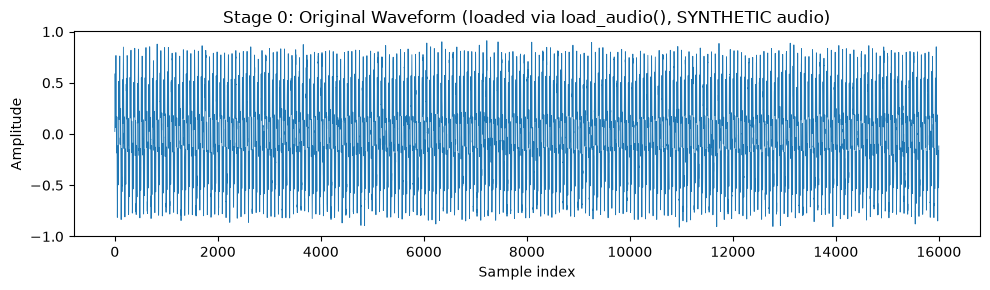

In [5]:
audio = load_audio(TEST_WAV_PATH)

print("Loaded samples:", len(audio), "| duration:", len(audio) / SAMPLE_RATE, "s")
print("dtype:", audio.dtype, "| range: [", audio.min(), ",", audio.max(), "]")

plt.figure(figsize=(10, 3))
plt.plot(audio, linewidth=0.6)
plt.title("Stage 0: Original Waveform (loaded via load_audio(), SYNTHETIC audio)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


## Stage 1 — Pre-emphasis

Verifies `apply_preemphasis()` (alpha=0.97) boosts high frequencies via
`y[n] = x[n] - alpha * x[n-1]`. Zoomed-in overlay shows the high-pass effect.


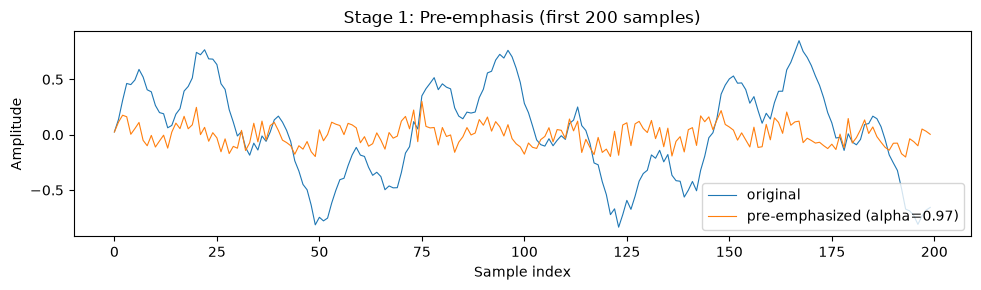

In [6]:
pre_emph = apply_preemphasis(audio)

assert pre_emph.shape == audio.shape

ZOOM = 200
plt.figure(figsize=(10, 3))
plt.plot(audio[:ZOOM], label="original", linewidth=0.8)
plt.plot(pre_emph[:ZOOM], label="pre-emphasized (alpha=0.97)", linewidth=0.8)
plt.title("Stage 1: Pre-emphasis (first 200 samples)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


## Stage 2 — Framing

Verifies `compute_frames()` splits the signal into overlapping 400-sample
(25ms) frames with a 160-sample (10ms) hop.


frames shape: (98, 400) (num_frames, FRAME_SAMPLES)


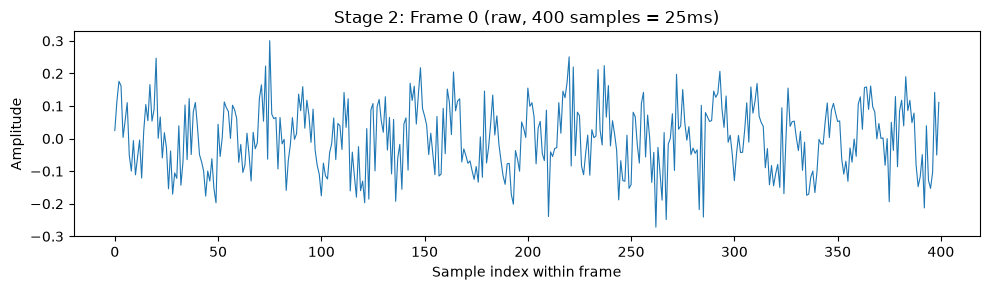

In [7]:
frames = compute_frames(pre_emph)

expected_num_frames = 1 + (len(pre_emph) - FRAME_SAMPLES) // HOP_SAMPLES
assert frames.shape == (expected_num_frames, FRAME_SAMPLES), frames.shape

print("frames shape:", frames.shape, "(num_frames, FRAME_SAMPLES)")

plt.figure(figsize=(10, 3))
plt.plot(frames[0], linewidth=0.8)
plt.title(f"Stage 2: Frame 0 (raw, {FRAME_SAMPLES} samples = 25ms)")
plt.xlabel("Sample index within frame")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


## Stage 3 — Hamming window

Verifies `apply_hamming()` tapers each frame's edges to reduce spectral
leakage before the FFT.


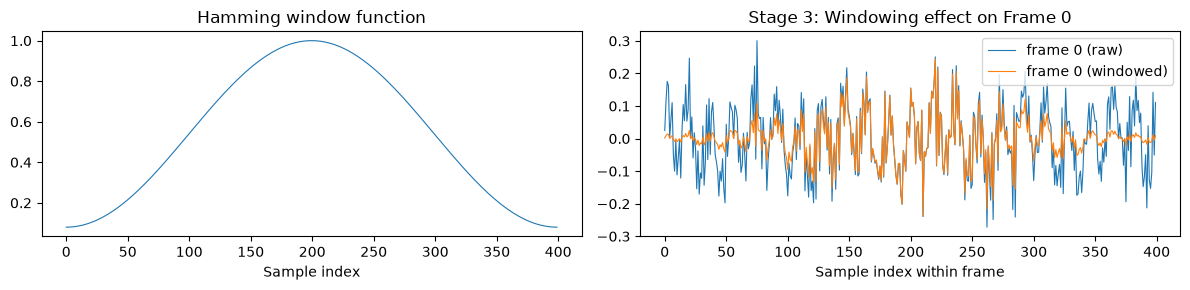

In [8]:
windowed = apply_hamming(frames)
hamming_window = np.hamming(FRAME_SAMPLES).astype(np.float32)

assert windowed.shape == frames.shape

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(hamming_window, linewidth=0.8)
axes[0].set_title("Hamming window function")
axes[0].set_xlabel("Sample index")

axes[1].plot(frames[0], label="frame 0 (raw)", linewidth=0.8)
axes[1].plot(windowed[0], label="frame 0 (windowed)", linewidth=0.8)
axes[1].set_title("Stage 3: Windowing effect on Frame 0")
axes[1].set_xlabel("Sample index within frame")
axes[1].legend()
plt.tight_layout()
plt.show()


## Stage 4 — FFT / Power spectrum

Verifies `compute_power_spectrum()` zero-pads each 400-sample frame to 512
points, computes the FFT, and returns power = real^2 + imag^2.


power spectrum shape: (98, 257) (num_frames, FFT_SIZE//2 + 1)


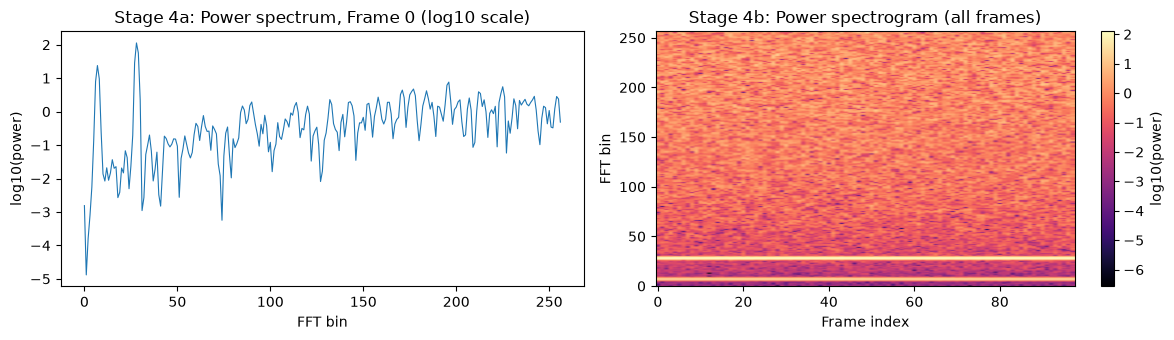

In [9]:
power = compute_power_spectrum(windowed)

assert power.shape == (frames.shape[0], FFT_SIZE // 2 + 1), power.shape
print("power spectrum shape:", power.shape, "(num_frames, FFT_SIZE//2 + 1)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].plot(np.log10(power[0] + 1e-10), linewidth=0.8)
axes[0].set_title("Stage 4a: Power spectrum, Frame 0 (log10 scale)")
axes[0].set_xlabel("FFT bin")
axes[0].set_ylabel("log10(power)")

im = axes[1].imshow(
    np.log10(power.T + 1e-10),
    aspect="auto",
    origin="lower",
    cmap="magma",
)
axes[1].set_title("Stage 4b: Power spectrogram (all frames)")
axes[1].set_xlabel("Frame index")
axes[1].set_ylabel("FFT bin")
fig.colorbar(im, ax=axes[1], label="log10(power)")

plt.tight_layout()
plt.show()


## Stage 5 — Mel filterbank

Verifies `build_mel_filterbank()` builds 26 triangular filters spanning
80-8000 Hz on the Mel scale.


Mel filterbank shape: (26, 257) (N_MEL, FFT_SIZE//2 + 1)


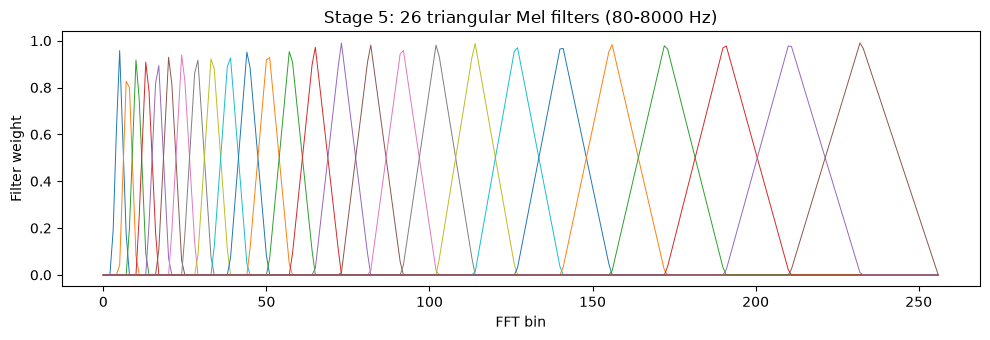

In [10]:
mel_fb = build_mel_filterbank()

assert mel_fb.shape == (N_MEL, FFT_SIZE // 2 + 1), mel_fb.shape
print("Mel filterbank shape:", mel_fb.shape, "(N_MEL, FFT_SIZE//2 + 1)")

plt.figure(figsize=(10, 3.5))
for m in range(N_MEL):
    plt.plot(mel_fb[m], linewidth=0.7)
plt.title(f"Stage 5: {N_MEL} triangular Mel filters ({MEL_FMIN:.0f}-{MEL_FMAX:.0f} Hz)")
plt.xlabel("FFT bin")
plt.ylabel("Filter weight")
plt.tight_layout()
plt.show()


## Stage 6 — Mel energies + log compression

Verifies `apply_mel_filterbank()` and `apply_log()` (epsilon=1e-6).


mel_energy shape: (98, 26)
log_mel shape: (98, 26) | range: [ -4.7533536 , 5.267725 ]


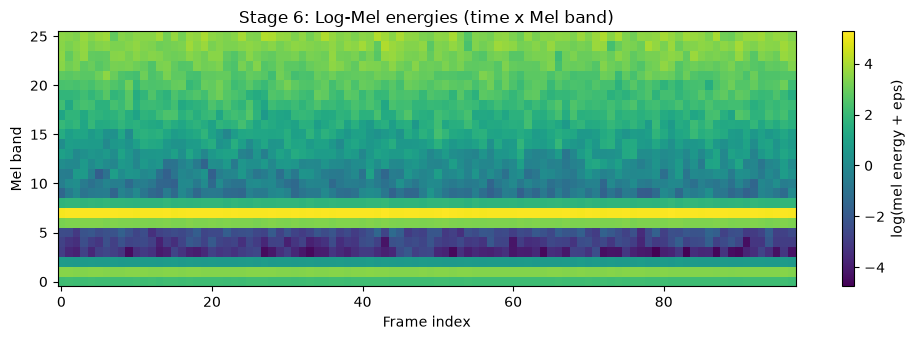

In [11]:
mel_energy = apply_mel_filterbank(power)
log_mel = apply_log(mel_energy)

assert mel_energy.shape == (frames.shape[0], N_MEL), mel_energy.shape
assert log_mel.shape == mel_energy.shape

print("mel_energy shape:", mel_energy.shape)
print("log_mel shape:", log_mel.shape, "| range: [", log_mel.min(), ",", log_mel.max(), "]")

plt.figure(figsize=(10, 3.5))
im = plt.imshow(log_mel.T, aspect="auto", origin="lower", cmap="viridis")
plt.title("Stage 6: Log-Mel energies (time x Mel band)")
plt.xlabel("Frame index")
plt.ylabel("Mel band")
plt.colorbar(im, label="log(mel energy + eps)")
plt.tight_layout()
plt.show()


## Stage 7 — DCT-II (raw MFCC, before pad/trim)

Verifies `apply_dct()` decorrelates the log-Mel energies and keeps the first
13 coefficients. Note: this is the *raw* frame count from framing, not yet
padded/trimmed to the canonical 49 frames (that happens inside
`extract_mfcc()` itself — not duplicated here).


raw MFCC shape (pre pad/trim): (98, 13)


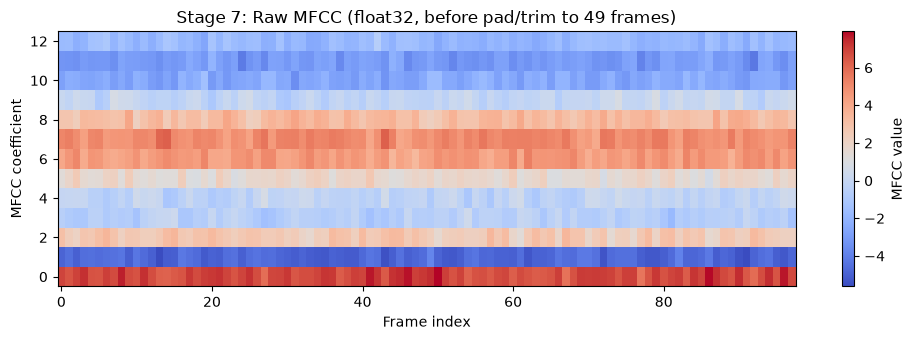

In [12]:
mfcc_raw = apply_dct(log_mel)

assert mfcc_raw.shape == (frames.shape[0], N_MFCC), mfcc_raw.shape
print("raw MFCC shape (pre pad/trim):", mfcc_raw.shape)

plt.figure(figsize=(10, 3.5))
im = plt.imshow(mfcc_raw.T, aspect="auto", origin="lower", cmap="coolwarm")
plt.title("Stage 7: Raw MFCC (float32, before pad/trim to 49 frames)")
plt.xlabel("Frame index")
plt.ylabel("MFCC coefficient")
plt.colorbar(im, label="MFCC value")
plt.tight_layout()
plt.show()


## Stage 8 — Canonical output: pad/trim + quantization

From here on we call the **actual public `extract_mfcc()` function** (not a
reimplementation) to get the pad/trim-to-49-frames and quantization steps,
since that logic lives inside `extract_mfcc()` and isn't exposed as separate
stage functions. This guarantees the notebook can never drift from the
canonical implementation.

- `quantize=False` -> float32 (49, 13), padded/trimmed, before quantization
- `normalize_and_quantize()` (imported, not duplicated) -> int8, shown
  separately then cross-checked against `quantize=True` for equality.


Padded/trimmed float32 MFCC shape: (49, 13) dtype: float32


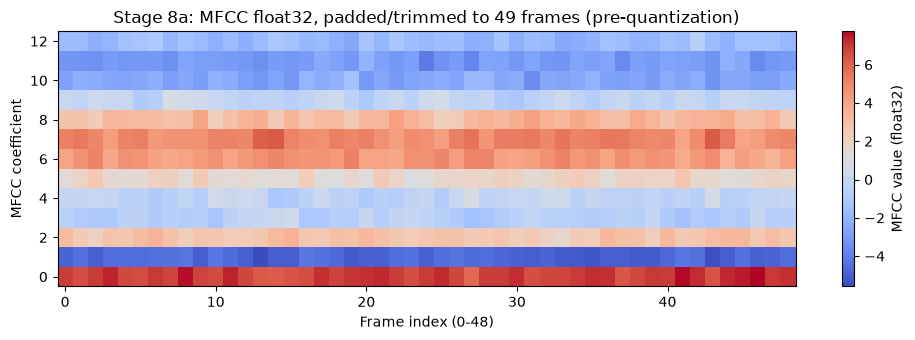

In [13]:
mfcc_float_49 = extract_mfcc(TEST_WAV_PATH, target_frames=49, quantize=False)
assert mfcc_float_49.shape == (49, N_MFCC), mfcc_float_49.shape
assert mfcc_float_49.dtype == np.float32

print("Padded/trimmed float32 MFCC shape:", mfcc_float_49.shape, "dtype:", mfcc_float_49.dtype)

plt.figure(figsize=(10, 3.5))
im = plt.imshow(mfcc_float_49.T, aspect="auto", origin="lower", cmap="coolwarm")
plt.title("Stage 8a: MFCC float32, padded/trimmed to 49 frames (pre-quantization)")
plt.xlabel("Frame index (0-48)")
plt.ylabel("MFCC coefficient")
plt.colorbar(im, label="MFCC value (float32)")
plt.tight_layout()
plt.show()


Cross-check OK: normalize_and_quantize(float49) == extract_mfcc(quantize=True)

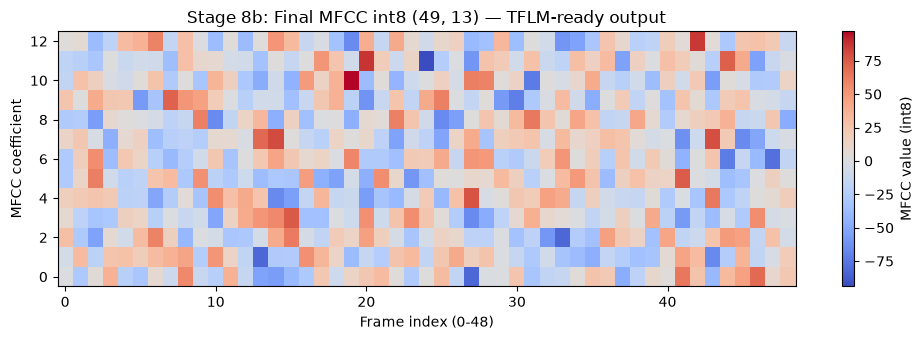

In [14]:
mfcc_int8_manual = normalize_and_quantize(mfcc_float_49)
mfcc_int8_canonical = extract_mfcc(TEST_WAV_PATH, target_frames=49, quantize=True)

assert np.array_equal(mfcc_int8_manual, mfcc_int8_canonical), (
    "normalize_and_quantize(quantize=False output) must equal extract_mfcc(quantize=True)"
)
print("Cross-check OK: normalize_and_quantize(float49) == extract_mfcc(quantize=True)")

plt.figure(figsize=(10, 3.5))
im = plt.imshow(mfcc_int8_canonical.T, aspect="auto", origin="lower", cmap="coolwarm")
plt.title("Stage 8b: Final MFCC int8 (49, 13) — TFLM-ready output")
plt.xlabel("Frame index (0-48)")
plt.ylabel("MFCC coefficient")
plt.colorbar(im, label="MFCC value (int8)")
plt.tight_layout()
plt.show()


## Final verification

Confirms the canonical `extract_mfcc()` output matches the frozen interface
contract required by S2: shape `(49, 13)`, dtype `int8`.


In [15]:
assert mfcc_int8_canonical.shape == (49, 13), f"shape mismatch: {mfcc_int8_canonical.shape}"
assert mfcc_int8_canonical.dtype == np.int8, f"dtype mismatch: {mfcc_int8_canonical.dtype}"

print("VERIFICATION PASSED")
print("shape:", mfcc_int8_canonical.shape)
print("dtype:", mfcc_int8_canonical.dtype)
print("min:", mfcc_int8_canonical.min(), "max:", mfcc_int8_canonical.max())
print("input WAV (synthetic):", TEST_WAV_PATH)


VERIFICATION PASSED
shape: (49, 13)
dtype: int8
min: -94 max: 97
input WAV (synthetic): C:\Users\ANSHIT~1\AppData\Local\Temp\s1_notebook_synthetic_test.wav
